# Reproducing Figure 2F-H (Huttlin et al. 2021, *Cell* 184:3022-3040)

This notebook reproduces the structural-context panels from Figure 2 of "Dual proteome-scale networks reveal cell-specific remodeling of the human interactome" (the BioPlex 3.0 / HCT116 paper), for the paper's own three example complexes:

- **Panel F**: TFIIH core complex, PDB `6NMI`
- **Panel G**: Ribonuclease P, PDB `6AHR` (includes the H1 RNA)
- **Panel H**: CDC45-MCM-GINS helicase, PDB `6XTX` (includes DNA)

Each figure has four panels (matching the paper's own layout):

1. **Structure**: the PDB structure, ray-traced via PyMOL and colored by chain.
2. **PDB Direct Interaction Network**: nodes colored to match the structure's chains; solid edges = protein-protein pairs with atoms <6 Å apart (a "direct" interaction, per `get_interacting_chains_from_PDB`); dashed edges = protein-nucleic acid contacts.
3. **BioPlex Direct Interactions**: the same edges, recolored green if that pair was also detected by BioPlex AP-MS in 293T cells, gray if not.
4. **All BioPlex Interactions**: the full BioPlex subnetwork among the structure's proteins across *both* cell lines, edges colored by which cell line(s) detected them (293T red / HCT116 blue / both gray) and styled by direct (bold) vs. indirect (thin).

Rendered via `render_figure2_panels_static()` (PyMOL-based, produces a single static image per structure) rather than the interactive `py3Dmol` path, so the output is viewable directly in this notebook -- including on GitHub -- without running any code. Requires the optional `pymol-open-source` package (`pip install bioplexpy[static-render]`).

In [1]:
from bioplexpy import getBioPlex
from bioplexpy.visualization_funcs import render_figure2_panels_static

# BioPlex 3.0 (293T, 118,162 interactions) and the HCT116 network
# (70,966 interactions) -- these are the two networks compared throughout
# the paper.
bp_293t = getBioPlex('293T', '3.0')
bp_hct116 = getBioPlex('HCT116', '1.0')

## Panel F: TFIIH core complex (PDB 6NMI)

Protein-only structure (MNAT1, ERCC2, ERCC3, GTF2H1-5) -- the simplest case, no nucleic acid chains.

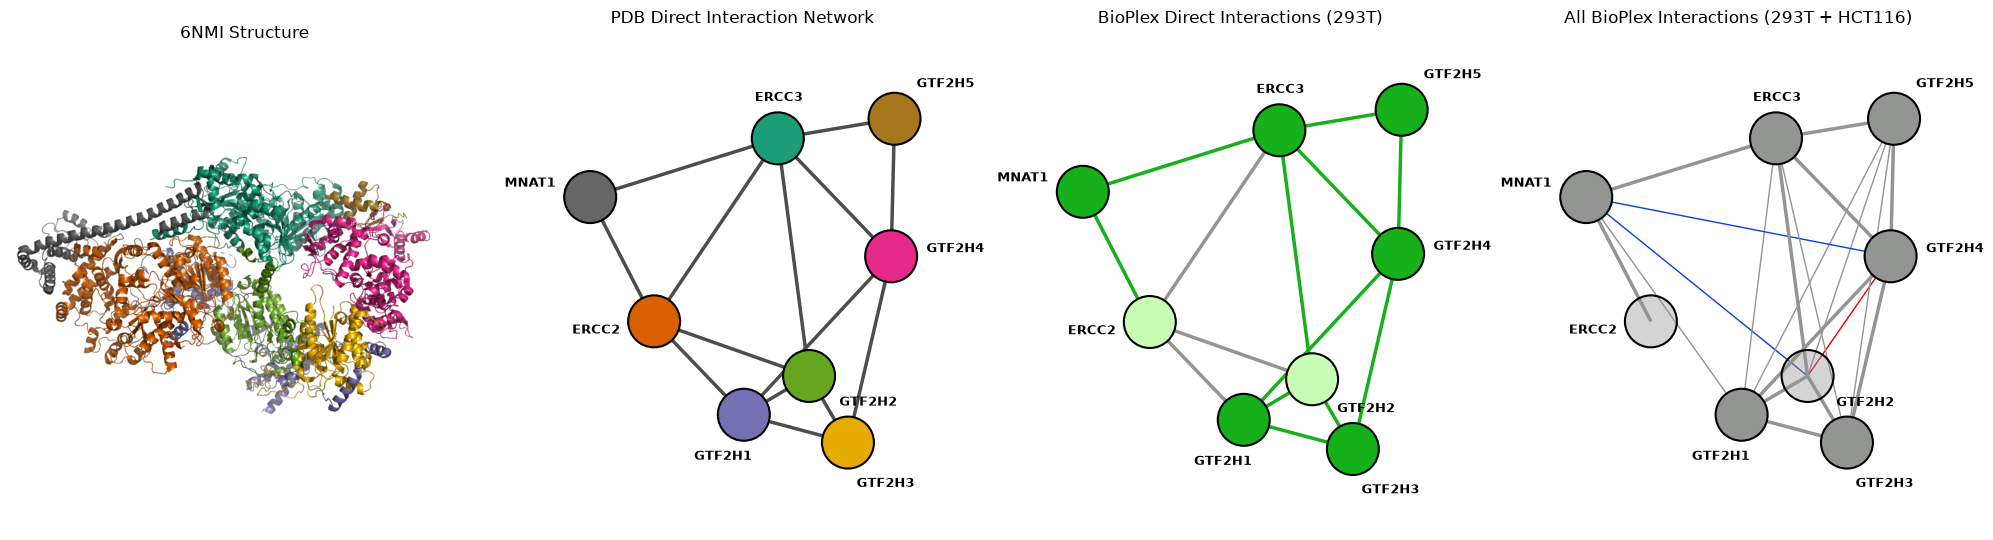

In [2]:
fig_F = render_figure2_panels_static('6NMI', '.', bp_293t, bp_hct116)

# An interactive alternative also exists: render_figure2_panels() returns
# (fig, view) instead of just fig, where `view` is a py3Dmol.view you can
# call .show() on for a rotatable 3D structure. Not used here -- calling
# .show() embeds the raw structure data as JavaScript in the notebook
# (~15-20MB per structure), which is why this notebook uses the static
# PyMOL-rendered image above instead.
#
# from bioplexpy.visualization_funcs import render_figure2_panels
# fig_F, view_F = render_figure2_panels('6NMI', '.', bp_293t, bp_hct116)
# view_F.show()

## Panel G: Ribonuclease P (PDB 6AHR)

Includes the H1 RNA subunit (chain A), which has no UniProt ID -- it's labeled `RNA:A` and drawn with dashed edges to its protein contacts, and correctly excluded from the "All BioPlex Interactions" panel since AP-MS only profiles proteins.

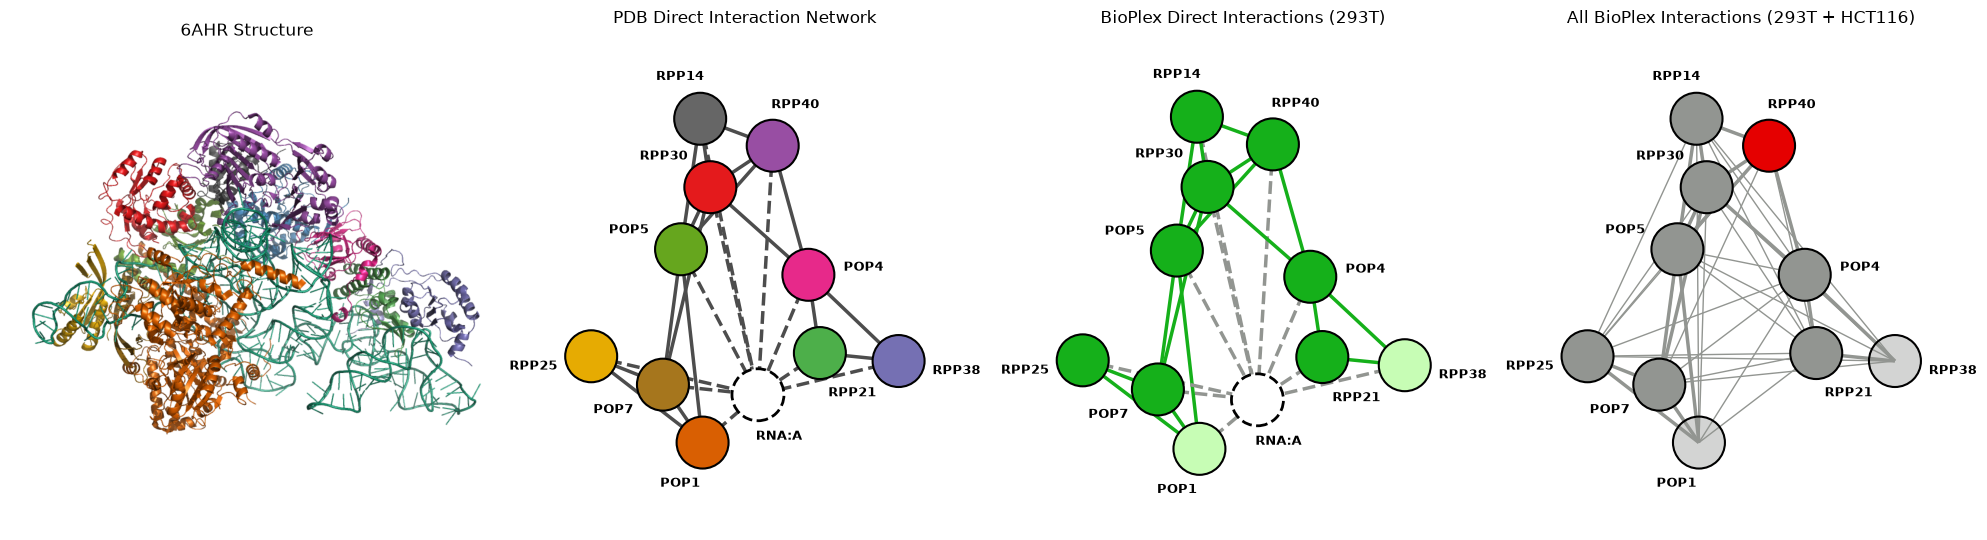

In [3]:
fig_G = render_figure2_panels_static('6AHR', '.', bp_293t, bp_hct116)

## Panel H: CDC45-MCM-GINS helicase (PDB 6XTX)

Includes a DNA chain (chain M, labeled `DNA:M`). The paper notes this complex's interactions are largely 293T-specific -- the "All BioPlex Interactions" panel below should show mostly red (293T-only) edges rather than black (shared).

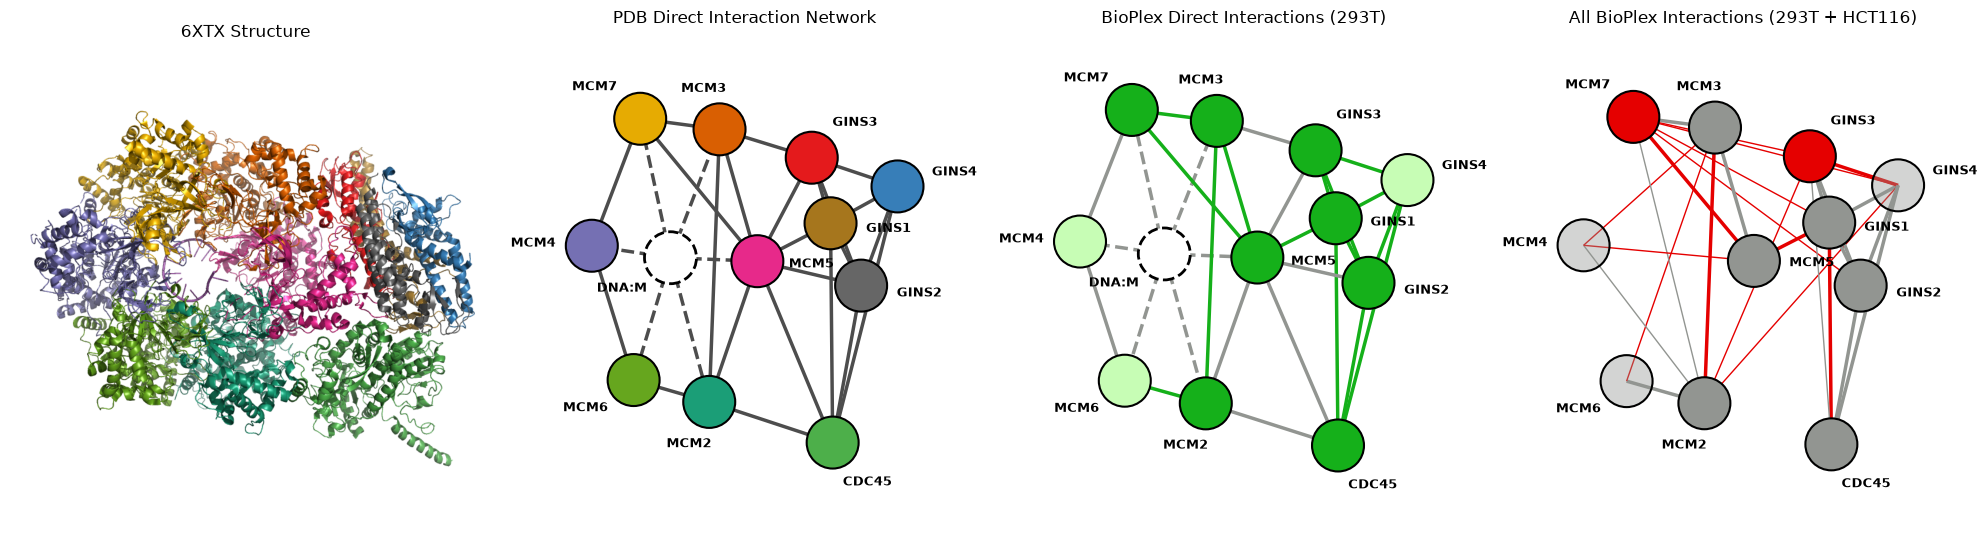

In [4]:
fig_H = render_figure2_panels_static('6XTX', '.', bp_293t, bp_hct116)